# VHH SMEFT predictions — NNLO QCD

This notebook computes **linear SMEFT** predictions for $W^\pm HH$ and $ZHH$ at **LO**
and **NNLO QCD** (for $ZHH$ the NNLO entry is the HHZ contribution), for the LHC at 13.6 or 14 TeV.

The cross section expands as $\sigma = \sigma_{\mathrm{SM}} + \sum_i B_i C_i$
with Wilson coefficients $C_i$ in $\mathrm{TeV}^{-2}$ and $B_i$ in $\mathrm{fb}\times \mathrm{TeV}^2$
bundled under `data/SMEFT/`.

> **Install once** with `pip install -e ".[notebook]"` (package only), then open this
> notebook from the repo root. Restart the kernel after editing `vhh_predict/`.

> For **HEFT** $\kappa$ predictions use [`vhh_prediction_HEFT.ipynb`](vhh_prediction_HEFT.ipynb).

## Contents

| § | What it does | Main output |
|---|---|---|
| Setup | Editable install check + imports | — |
| 1 | Process, energy, output flags | `analysis` |
| 2 | Spot check at one WC point | results table (+ simulation if enabled) |
| 3 | Scan one WC axis and plot | `scan_data` + PNGs (+ optional `.txt`) |
| 4 | Joint multi-axis grid scan | one `results/points/smeft/<Process>/<energy>/*_x_*.txt` |
| 5 | SMEFT benchmark tables | display + `results/tables/smeft/smeft_publication_tables.tex` |

See [README.md](README.md) for an overview; `AGENTS.md` for the package API.


## Setup

Requires an editable install from the repo root (defined in `pyproject.toml`):

```bash
pip install -e ".[notebook]"
```

Then `import vhh_predict` works — notebooks do **not** modify `sys.path`.
Restart the kernel after changing package code.


In [1]:
from vhh_predict.analysis import package_root, smeft_wc_intervals_path

REPO_ROOT = package_root()
if not (REPO_ROOT / "data" / "SMEFT").is_dir() or not (REPO_ROOT / "vhh_predict").is_dir():
    raise RuntimeError(
        f"Expected 'data/SMEFT/' and 'vhh_predict/' under {REPO_ROOT}.\n"
        "Install from the repo root:  pip install -e \".[notebook]\"\n"
        "Then start Jupyter from that same directory."
    )

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from vhh_predict.plot_style import (
    PlotStyle,
    default_plot_title,
    plot_style_with_layout,
    scan_plot_path,
)
from vhh_predict.plots import (
    plot_sigma_nnlo_and_enhancement_nnlo,
    plot_sigma_nnlo_and_kfactor,
)
from vhh_predict.smeft_analysis import load_smeft_analysis
from vhh_predict.smeft_core import resolve_scan_axis, spot_check_caption, spot_check_table
from vhh_predict.smeft_operators import (
    SMEFT_WC_INTERVALS,
    SMEFT_WC_PLAIN,
    scan_axes,
    sm_wc_values,
)
from vhh_predict.smeft_scan_io import scan_and_save, scan_grid_and_save
from vhh_predict.smeft_tables import (
    CHANNELS,
    TABLE_ENERGIES_TEV,
    build_channel_tables,
    latex_publication_tables,
)


print(f"Repo root: {REPO_ROOT}")


Repo root: /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO


## 1. Configuration

| Variable | Meaning |
|----------|---------|
| `PROCESS` | `"WplusHH"`, `"WminusHH"`, or `"ZHH"` |
| `ENERGY_TEV` | `13.6` or `14.0` |
| `COMPARE_SIMULATION` | Compare to bundled SMEFT `.out` files in §2 only |
| `UNCERTAINTIES_AS_PERCENT` | Print uncertainties as % (`False` → fb) |
| `SAVE_SCAN_POINTS` | Write §3 / §4 scan tables to `results/points/smeft/<Process>/<energy>/` |
| `SAVE_PLOTS` | Write §3 plot PNGs to `results/plots/smeft/<Process>/<energy>/` |
| `SIGMA_INSET`, `LEGEND_LOC`, `INSET_LOC` | Plot layout (§3) |

Wilson coefficients $C_i$ in $\mathrm{TeV}^{-2}$. SM point: all $C_i = 0$.

Use **Key** in `WCS` / scans / `predict`, e.g. `{"phiW": -0.2}` or `scan_axis = "phiW"`
(`SMEFT_WC_INTERVALS` in `vhh_predict/smeft_operators.py`).

### Bosonic

| WC | Key | Interval $[\mathrm{TeV}^{-2}]$ |
|----|-----|-------------------------------|
| $C_\varphi$ | `phi` | [−15, 5] |
| $C_{\varphi W}$ | `phiW` | [−1, 1] |
| $C_{\varphi B}$ | `phiB` | [−0.5, 0.5] |
| $C_{\varphi WB}$ | `phiWB` | [−1.5, 1.5] |
| $C_{\varphi D}$ | `phiD` | [−1.5, 1.5] |
| $C_{\varphi\square}$ | `phiBox` | [−2, 2] |

### Fermionic

| WC | Key | Interval $[\mathrm{TeV}^{-2}]$ |
|----|-----|-------------------------------|
| $C_{\varphi q}^{(3)}$ | `phiq3st` | [−0.2, 0.05] |
| $C_{\varphi t}$ | `phit` | [−25, 34] |
| $C_{\varphi Q}^{(3)}$ | `phiQ3` | [−8, 2] |
| $C_{\varphi Q}^{(1)}$ | `phiQ1rd` | [−6.5, 30.5] |
| $C_{\varphi t}+C_{\varphi Q}^{(3)}-C_{\varphi Q}^{(1)}$ | `phiQ3rd` | [−8, 2] |
| $C_{\varphi q}^{(1)}$ | `phiq1st` | [−3, 1] |
| $C_{\varphi u}$ | `phiu` | [−3.5, 1] |
| $C_{\varphi d}$ | `phid` | [−4, 4] |
| $C_{t\varphi}$ | `tphi` | [−15, 5] |


In [2]:
PROCESS = "ZHH"
ENERGY_TEV = 13.6

COMPARE_SIMULATION = True
UNCERTAINTIES_AS_PERCENT = True
SAVE_SCAN_POINTS = True
SAVE_PLOTS = True


SIGMA_INSET = True
LEGEND_LOC = "lower right"
INSET_LOC = "upper left"

PLOT_STYLE = plot_style_with_layout(
    legend_loc=LEGEND_LOC,
    inset_loc=INSET_LOC,
    sigma_inset=SIGMA_INSET,
    base=PlotStyle(inset_x_start_fraction=0.10),
)

analysis = load_smeft_analysis(PROCESS, ENERGY_TEV)
nn_label = analysis.nnlo_label

print(f"{PROCESS} @ {ENERGY_TEV} TeV  |  scan axes: {', '.join(scan_axes(PROCESS))}")


ZHH @ 13.6 TeV  |  scan axes: phi, phiBox, phiD, phiq3st, phiW, phiq1st, phiu, phid, phiB, phiWB, tphi, phiQ3rd


## 2. Spot check

Set **`WCS`** — a dictionary of Wilson coefficients in $\mathrm{TeV}^{-2}$.
Unlisted coefficients default to 0 (SM).

Example for $ZHH$: `{"phiW": -0.2}` sets $C_{\varphi W} = -0.2$ with all other $C_i = 0$.

The table shows **$\sigma_{\mathrm{LO}}$**, **$\sigma_{\mathrm{NNLO}}$**, and the **$K$-factor**, with scale / PDF+$\alpha_s$ uncertainties.
For $ZHH$, $\sigma_{\mathrm{NNLO}}$ is the HHZ contribution (still labelled NNLO).
When `COMPARE_SIMULATION=True`, matching `.out` files under `data/SMEFT/.../Simulation/` are compared if available.


In [3]:
WCS = {"phiBox": -1}  # SM: {} or all zeros

display(Markdown(f"### {spot_check_caption(analysis, WCS)}"))
display(
    spot_check_table(
        analysis,
        WCS,
        as_percent=UNCERTAINTIES_AS_PERCENT,
        compare_simulation=COMPARE_SIMULATION,
    )
)


### ZHH @ 13.6 TeV — C_φ□=-1

,Quantity,SMEFT,Scale (+/−),PDF+αs,Simulation,Δ vs simulation
0,σ_LO [fb],0.0719313,+0.78% / −1.02%,±6.35%,0.0725231,-0.82%
1,σ_NNLO [fb],0.117769,+7.36% / −5.54%,±4.84%,0.119829,-1.72%
2,K,1.63724,—,—,1.65228,-0.91%


## 3. Scan and plots

Vary **one** Wilson coefficient; all others stay at **0** (SM).

- `scan_axis` — one of the keys printed in §1 (`phi`, `phiW`, …)
- `scan_vmin`, `scan_vmax` — scan window (defaults below use the global-fit interval)
- `scan_n_points` — grid resolution


Interval for C_φW: [-0.4, 1]
Scan / plot window:                  [-0.4, 1]
Saved /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/results/points/smeft/ZHH/13_6TeV/ZHH_13.6TeV_phiW.txt


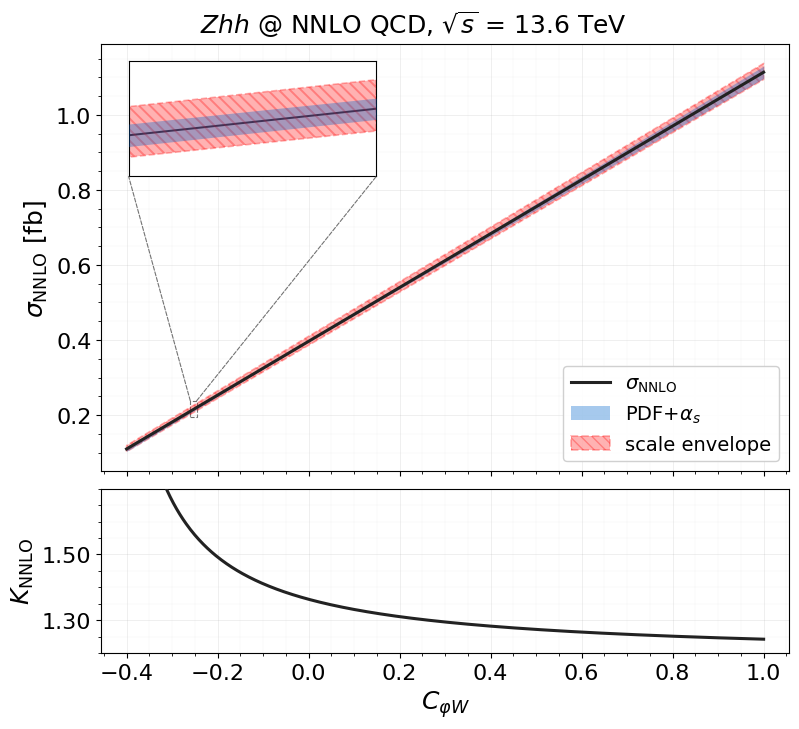

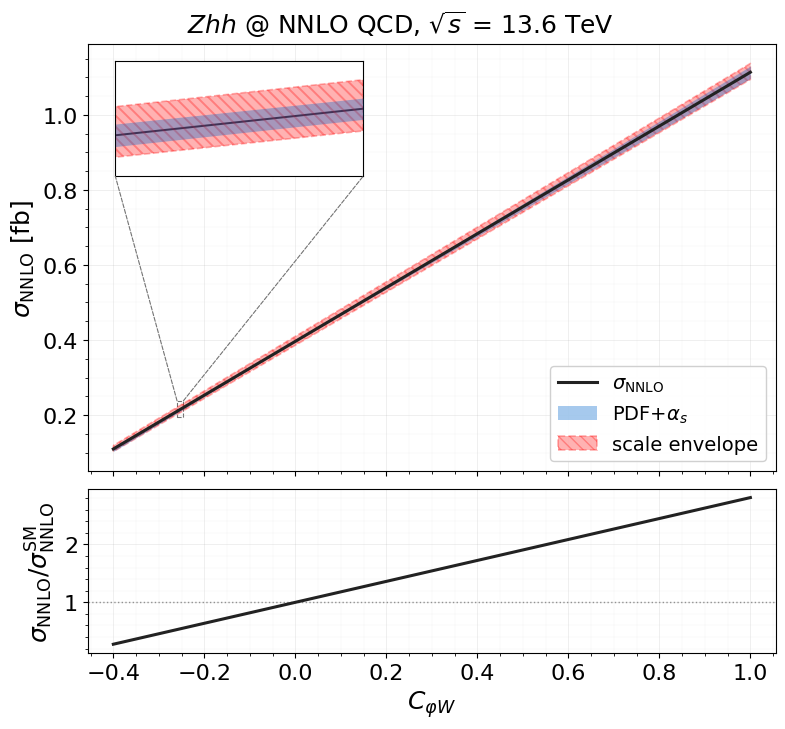

In [4]:
scan_axis = "phiW"
scan_vmin, scan_vmax = [-0.4,1]
scan_n_points = 400

print(f"Interval for {SMEFT_WC_PLAIN[scan_axis]}: [{scan_vmin:g}, {scan_vmax:g}]")
print(f"Scan / plot window:                  [{scan_vmin:g}, {scan_vmax:g}]")

scan_data, scan_points_file = scan_and_save(
    analysis,
    scan_axis,
    vmin=scan_vmin,
    vmax=scan_vmax,
    n_points=scan_n_points,
    uncertainties=True,
    save=SAVE_SCAN_POINTS,
)
if SAVE_SCAN_POINTS:
    print(f"Saved {scan_points_file}")

_, scan_x_key = resolve_scan_axis(PROCESS, scan_axis)
plot_title = default_plot_title(PROCESS, ENERGY_TEV, nn_label)
_nnlo_kw = dict(
    style=PLOT_STYLE,
    nnlo_label=nn_label,
    xmin=scan_vmin,
    xmax=scan_vmax,
    save=SAVE_PLOTS,
)

plot_sigma_nnlo_and_kfactor(
    scan_data,
    title=plot_title,
    process=PROCESS,
    sigma_inset=SIGMA_INSET,
    output=scan_plot_path("SMEFT", PROCESS, ENERGY_TEV, scan_x_key, scan_vmin, scan_vmax, "sigma_nnlo_K"),
    **_nnlo_kw,
)
plt.show()

plot_sigma_nnlo_and_enhancement_nnlo(
    scan_data,
    title=plot_title,
    sigma_inset=SIGMA_INSET,
    show_enhancement_uncertainty=False,
    output=scan_plot_path("SMEFT", PROCESS, ENERGY_TEV, scan_x_key, scan_vmin, scan_vmax, f"sigma_nnlo_sigmaSM_{nn_label}"),
    **_nnlo_kw,
)
plt.show()


## 4. Joint multi-axis scan (Cartesian grid)

Vary **all** listed Wilson coefficients **at once** (Cartesian product) and write **one** `.txt` under `results/points/smeft/<Process>/<energy>/`.
Non-scanned $C_i$ stay at **0** (SM).

- `BATCH_SCAN_AXES` — axes to vary jointly
- `BATCH_SCAN_WINDOWS` — optional `{axis: (vmin, vmax)}`; omitted axes use `SMEFT_WC_INTERVALS`
- `BATCH_SCAN_N_POINTS` — points **per axis** (2 × 40 → 1600 rows)

Set `BATCH_SCAN_AXES = ()` to skip.


In [5]:
BATCH_SCAN_AXES = (
    "phi",
    "phiW",
)
BATCH_SCAN_N_POINTS = 40  # per axis → 40×40 = 1600 points for 2 axes
BATCH_SCAN_WINDOWS = {}

if BATCH_SCAN_AXES:
    from vhh_predict.smeft_core import resolve_scan_axis

    scan_data, path = scan_grid_and_save(
        analysis,
        BATCH_SCAN_AXES,
        windows=BATCH_SCAN_WINDOWS or None,
        n_points=BATCH_SCAN_N_POINTS,
        save=SAVE_SCAN_POINTS,
        uncertainties=False,
    )
    n_total = len(next(iter(scan_data.values())))
    print(f"Joint grid scan: {len(BATCH_SCAN_AXES)} axes × {BATCH_SCAN_N_POINTS} pts → {n_total} points")
    for axis in BATCH_SCAN_AXES:
        lo, hi = (BATCH_SCAN_WINDOWS or {}).get(axis) or SMEFT_WC_INTERVALS[axis]
        print(f"  {SMEFT_WC_PLAIN[axis]}  [{lo:g}, {hi:g}]")
    print(f"  →  {path if SAVE_SCAN_POINTS else '(not saved)'}")
else:
    print("Joint scan skipped (BATCH_SCAN_AXES is empty).")


Joint grid scan: 2 axes × 40 pts → 1600 points
  C_φ  [-15, 5]
  C_φW  [-1, 1]
  →  /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/results/points/smeft/ZHH/13_6TeV/ZHH_13.6TeV_phi_x_phiW.txt


## 5. SMEFT benchmark tables

σ tables cover **every** scan-axis Wilson coefficient (`scan_axes(PROCESS)`):

| Channel | Groups (display only) | WCs (keys) |
|---------|----------------------|------------|
| `WplusHH`, `WminusHH` | one table | `phi`, `phiW`, `phiD`, `phiBox`, `phiq3st` |
| `ZHH` | group 1 | `phi`, `phiW`, `phiD`, `phiBox`, `phiq3st` |
| `ZHH` | group 2 | `phiq1st`, `phiu`, `phid`, `phiQ3rd` |
| `ZHH` | group 3 | `tphi`, `phiB`, `phiWB` |

Each non-SM row uses the **interval endpoint that maximises** $\sigma_{\mathrm{NNLO}}$ for that WC (others held at SM = 0); there is no separate min/max Point column. Tables cover both 13.6 and 14 TeV. ZHH prints **one table per group**.

The LaTeX file `results/tables/smeft/smeft_publication_tables.tex` collects the manuscript-style SMEFT tables for all channels.

Grouping for ZHH is `ZHH_TABLE_GROUPS` in `vhh_predict/smeft_tables.py`; axes themselves come from `scan_axes`.


In [6]:
latex_path = smeft_wc_intervals_path()
latex_path.write_text(latex_publication_tables(), encoding="utf-8")
print(f"Saved publication tables: {latex_path}")

print("σ benchmark WCs (all scan axes):")
for process in CHANNELS:
    axes = scan_axes(process)
    print(f"  {process}: {', '.join(axes)}")

for process in CHANNELS:
    display(Markdown(f"## {process}"))
    tables = build_channel_tables(process, energies_tev=TABLE_ENERGIES_TEV)
    for key, df in tables.items():
        if process == "ZHH":
            axes = key.split("_")
            title = (
                f"({', '.join(axes)}) — "
                + ", ".join(SMEFT_WC_PLAIN.get(a, a) for a in axes)
            )
            display(Markdown(f"### {title}"))
        else:
            display(Markdown(f"### all scan axes ({', '.join(scan_axes(process))})"))
        display(df)


Saved publication tables: /Users/michalryczkowski/Documents/Programming/GitHub/VHH-NNLO/results/tables/smeft/smeft_publication_tables.tex
σ benchmark WCs (all scan axes):
  WplusHH: phi, phiBox, phiD, phiq3st, phiW
  WminusHH: phi, phiBox, phiD, phiq3st, phiW
  ZHH: phi, phiBox, phiD, phiq3st, phiW, phiq1st, phiu, phid, phiB, phiWB, tphi, phiQ3rd


## WplusHH

### all scan axes (phi, phiBox, phiD, phiq3st, phiW)

,√s [TeV],WC,σ_LO [fb],σ_NNLO [fb],K
0,13.6,SM,0.296715,0.357952,1.206382
1,13.6,C_φ=-15,1.415458,1.703594,1.203563
2,13.6,C_φW=1,1.228069,1.464890,1.192841
3,13.6,C_φD=1.5,0.320098,0.386285,1.206771
4,13.6,C_φ□=2,0.760532,0.917933,1.206963
5,13.6,C_φq^(3)=0.05,1.533285,1.876280,1.223700
6,14.0,SM,0.310613,0.374201,1.204717
7,14.0,C_φ=-15,1.480104,1.778987,1.201934
8,14.0,C_φW=1,1.288832,1.535630,1.191490
9,14.0,C_φD=1.5,0.335141,0.403879,1.205103


## WminusHH

...

,√s [TeV],WC,σ_LO [fb],σ_NNLO [fb],K
0,13.6,SM,0.290698,0.396408,1.363641
1,13.6,C_φ=-15,1.336500,1.671345,1.250539
2,13.6,C_φW=1,0.896660,1.113745,1.242103
3,13.6,C_φD=1.5,0.310917,0.423447,1.361929
4,13.6,C_φ□=2,0.728231,0.953684,1.309590
5,13.6,C_φq^(3)=0.05,0.386671,0.488529,1.263422
6,14.0,SM,0.305509,0.417277,1.365842
7,14.0,C_φ=-15,1.402997,1.754266,1.250370
8,14.0,C_φW=1,0.944377,1.172678,1.241748
9,14.0,C_φD=1.5,0.326818,0.445796,1.364051


### (phiq1st, phiu, phid, phiQ3rd) — C_φq^(1), C_φu, C_φd, C_φt+C_φQ^(3)−C_φQ^(1)

,√s [TeV],WC,σ_LO [fb],σ_NNLO [fb],K
0,13.6,SM,0.290698,0.396408,1.363641
1,13.6,C_φq^(1)=-3,4.051775,3.793777,0.936325
2,13.6,C_φu=1,0.373311,0.475935,1.274902
3,13.6,C_φd=-4,0.528916,0.651528,1.231818
4,13.6,C_φt+C_φQ^(3)−C_φQ^(1)=2,0.290698,0.403949,1.389583
5,14.0,SM,0.305509,0.417277,1.365842
6,14.0,C_φq^(1)=-3,3.585016,3.124734,0.871610
7,14.0,C_φu=1,0.380749,0.485950,1.276300
8,14.0,C_φd=-4,0.541366,0.666021,1.230260
9,14.0,C_φt+C_φQ^(3)−C_φQ^(1)=2,0.305509,0.425376,1.392351


### (tphi, phiB, phiWB) — C_tφ, C_φB, C_φWB

,√s [TeV],WC,σ_LO [fb],σ_NNLO [fb],K
0,13.6,SM,0.290698,0.396408,1.363641
1,13.6,C_tφ=-15,0.290698,0.455923,1.568375
2,13.6,C_φB=0.5,0.298345,0.405437,1.358952
3,13.6,C_φWB=-1.5,0.952005,1.181422,1.240983
4,14.0,SM,0.305509,0.417277,1.365842
5,14.0,C_tφ=-15,0.305509,0.480691,1.573412
6,14.0,C_φB=0.5,0.313558,0.426770,1.361054
7,14.0,C_φWB=-1.5,1.002270,1.243326,1.240510
